Data: 1,126 dot
Start: 2026-02-05 06:51:10.157000+00:00
End: 2026-02-17 08:10:24.161000+00:00


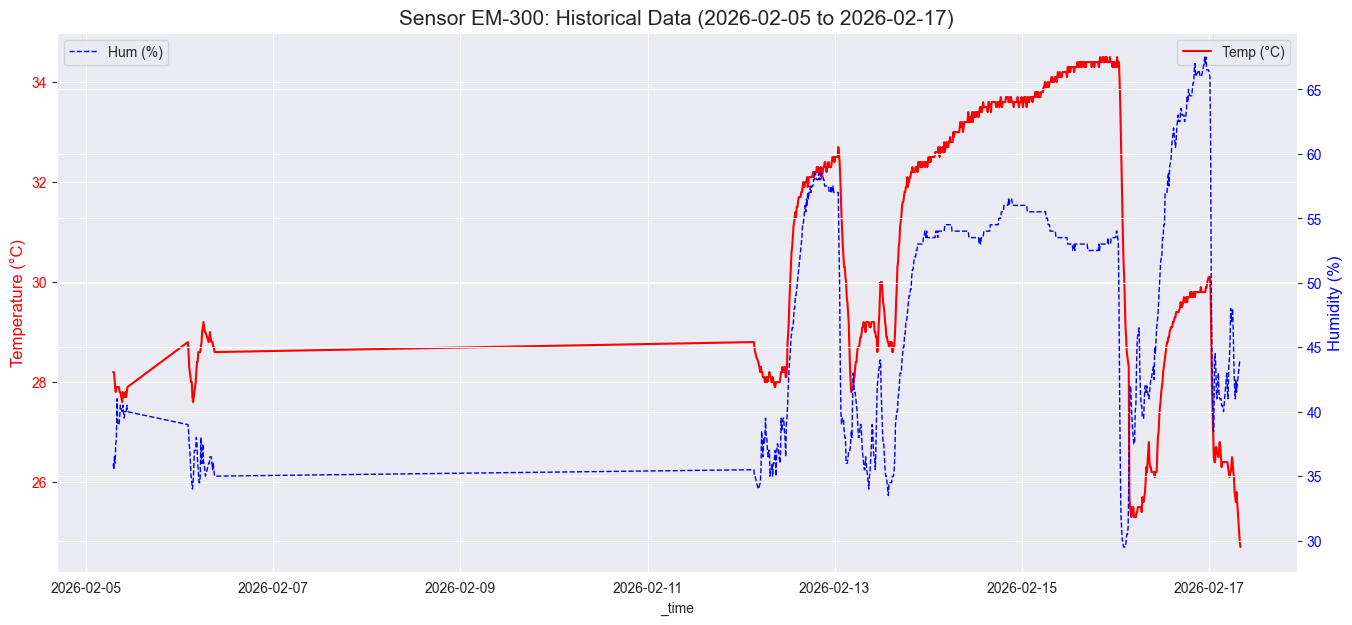

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'C:\Users\cheew\Desktop\Swift\Project\Training_Project\data\raw\sensor_data_raw.csv'
df = pd.read_csv(file_path)

df['_time'] = pd.to_datetime(df['_time'], errors='coerce')
df = df.dropna(subset=['_time'])

df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['hum'] = pd.to_numeric(df['hum'], errors='coerce')

df = df.sort_values('_time')

print(f"Data: {len(df):,} dot")
print(f"Start: {df['_time'].min()}")
print(f"End: {df['_time'].max()}")

plt.figure(figsize=(16, 7))
sns.set_style("darkgrid")

ax1 = plt.gca()
sns.lineplot(data=df, x='_time', y='temp', ax=ax1, color='red', label='Temp (°C)', linewidth=1.5)
ax1.set_ylabel('Temperature (°C)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
sns.lineplot(data=df, x='_time', y='hum', ax=ax2, color='blue', label='Hum (%)', linewidth=1, linestyle='--')
ax2.set_ylabel('Humidity (%)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title(f'Sensor EM-300: Historical Data ({df["_time"].min().date()} to {df["_time"].max().date()})', fontsize=15)
plt.xticks(rotation=45)
plt.show()